# (08) Animate hallucination mp4: Rot MNIST

host = ```mach```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## anim setup

In [3]:
from utils.animation import animate_recons


anim_dir = pjoin(tmp_dir, 'animations/hallucinate')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

[]

## Local helper functions

In [4]:
from analysis.final import perform_analysis, get_root_path

root = get_root_path()


def _quick_xtract_ftr_with_recons(t_total, d_theta=None, data_batch_sz=13):
    if d_theta is None:
        data = 'vld'
    else:
        data = tr.get_feeder(
            data='vld',
            data_batch_sz=data_batch_sz,
            max_delta_theta=d_theta,
            sample_uniform=False,
            theta_0=0,
        )[0]
        data.set_current_delta_theta(d_theta)

    output = tr.xtract_ftr(
        data=data,
        t_total=t_total,
        save_freq=1,
        data_batch_sz=data_batch_sz,
        n_data_batches=1,
        return_recon=True,
        verbose=False,
    )
    return output


def _quick_show_evolution_side_by_side(time_range, sample_i=0):
    x2p = np.concatenate([
        output['true'][sample_i, time_range],
        output['recon'][sample_i, time_range],
    ])
    plot_weights(x2p, nrows=2, method='min-max')
    plt.show()

## Load model (MNIST)

In [5]:
# # a = 'poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>'
# # b = 'b200-ep200-lr(0.001)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_26,10:47)'

# a = 'poisson_MNIST+rotate_t-(32,32)_b-8_kms-(192,8,3)_fwd-(3,7)_prob_<ngd|lin>'
# b = 'b100-ep200-lr(0.0005)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_29,09:02)'

# tr, meta = load_model(pjoin(a, b), device=device)
# meta['checkpoint']

fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_recon-mse_chewie-0_(2025_09_07,15:41)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

100

In [6]:
tr.print()

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(1,3)_<ngd|lin>
b200-ep100-lr(0.002)_temp(0.05)_gr(250)_(2025_09_07,15:41)

### sanity check

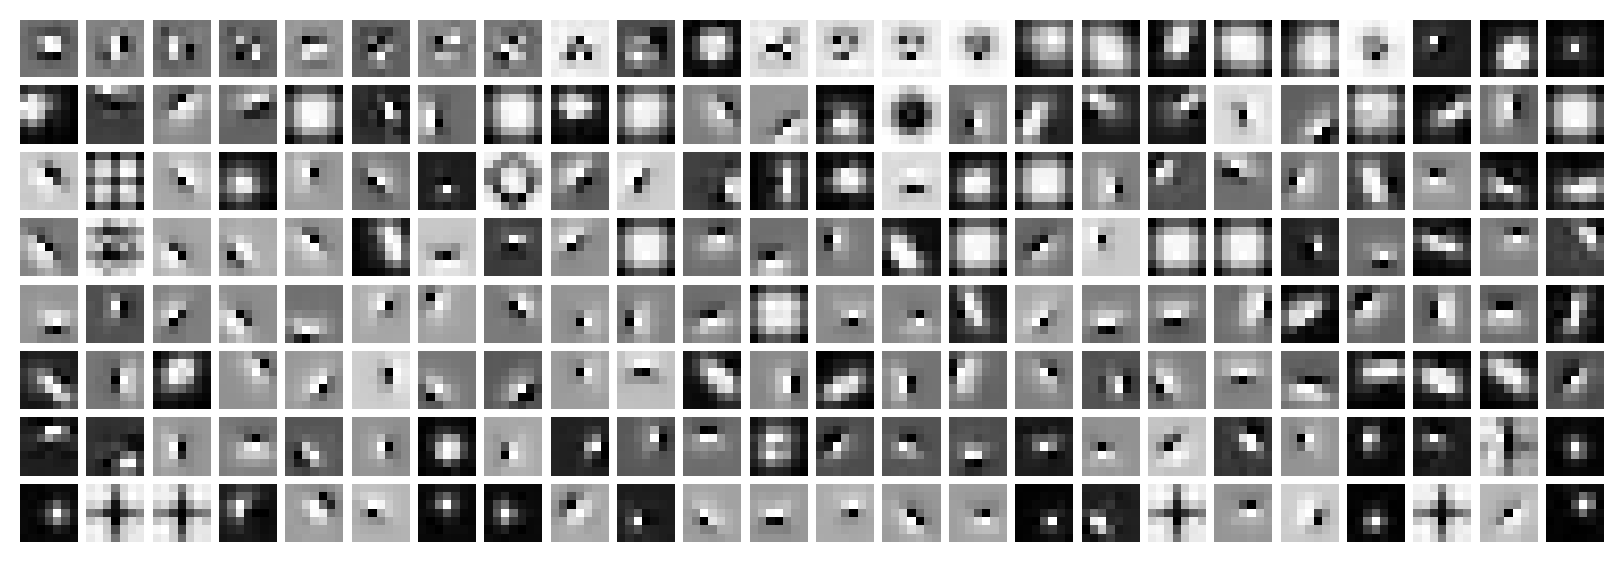

In [7]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [8]:
dt_str = '\n'.join([
    f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
    f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
])
print(dt_str)

dt_enc = 0.403
dt_fwd = 1.767

100%|███████████████████████████████████| 2/2 [00:57<00:00, 28.58s/it]


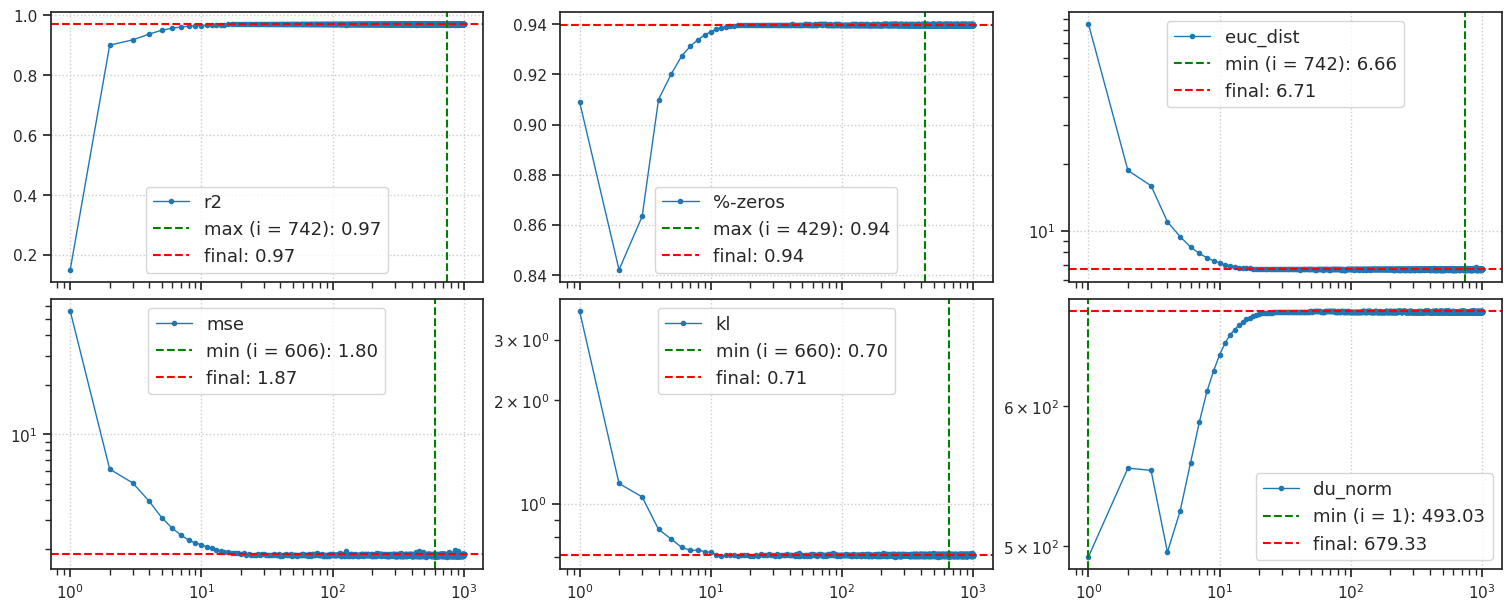

CPU times: user 58.3 s, sys: 496 ms, total: 58.8 s
Wall time: 58.8 s


In [9]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=2)
_ = plot_convergence(results=results, color='C0')

### predict into future

In [10]:
output = _quick_xtract_ftr_with_recons(t_total=40, d_theta=4.0)
list(output)

['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

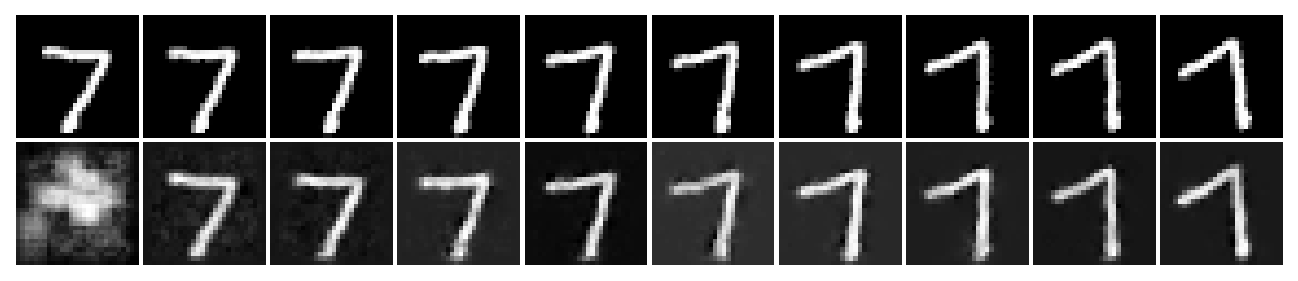

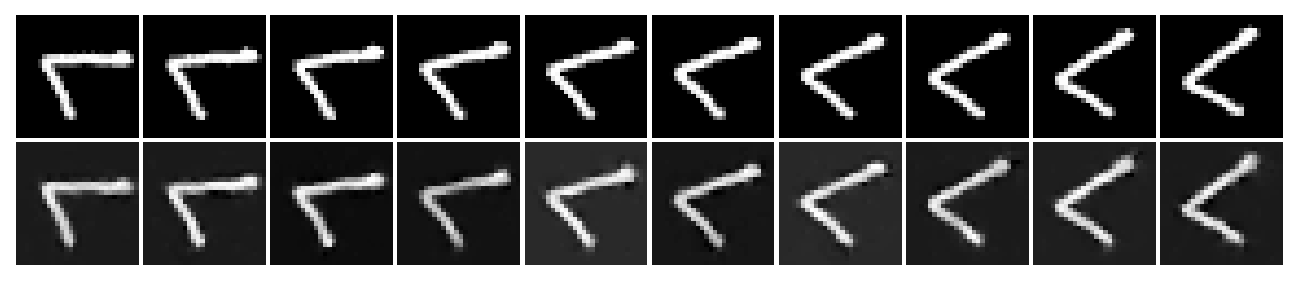

In [11]:
_quick_show_evolution_side_by_side(time_range=range(10))
_quick_show_evolution_side_by_side(time_range=range(30, 40))

In [12]:
layer = tr.model.layer
layer.conditional.loc.shape

torch.Size([13, 1, 28, 28])

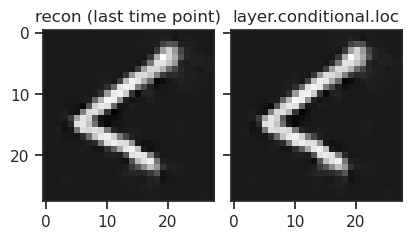

In [13]:
fig, axes = create_figure(1, 2, (4, 2.2), 'all', 'all')

axes[0].imshow(output['recon'][0, -1].squeeze(), cmap='Greys_r')
axes[1].imshow(tonp(layer.conditional.loc[0].squeeze()), cmap='Greys_r')
axes[0].set_title('recon (last time point)')
axes[1].set_title('layer.conditional.loc')
plt.show()

In [14]:
np.abs(output['recon'][0, -1].squeeze() - tonp(layer.conditional.loc[0].squeeze())).sum()

0.0

In [15]:
with layer.temporary_temperature(layer.cfg.validation_temp):
    layer.update_generative_state()

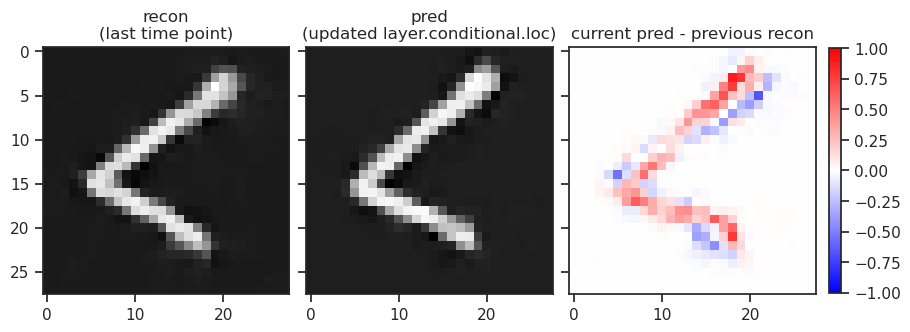

In [37]:
fig, axes = create_figure(1, 3, (9, 3.2), 'all', 'all')

axes[0].imshow(output['recon'][0, -1].squeeze(), cmap='Greys_r')
axes[1].imshow(tonp(layer.conditional.loc[0].squeeze()), cmap='Greys_r')

delta_imag = tonp(layer.conditional.loc[0].squeeze()) - output['recon'][0, -1].squeeze()
im = axes[2].imshow(delta_imag, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[2], shrink=0.88)

axes[0].set_title('recon\n(last time point)')
axes[1].set_title('pred\n(updated layer.conditional.loc)')
axes[2].set_title('current pred - previous recon')

plt.show()

In [38]:
x_init = layer.conditional.loc

samples_generated_x, samples_generated_z = tr.model.generate(
    n_samples=len(x_init), x_init=x_init, t_total=60, reset_state=False,
)
samples_generated_x.shape

(13, 60, 1, 28, 28)

In [43]:
from utils.animation import show_movie

show_movie(samples_generated_x[0].squeeze(), vmin=0, vmax=1)

In [44]:
show_movie(samples_generated_x[1].squeeze(), vmin=0, vmax=1)

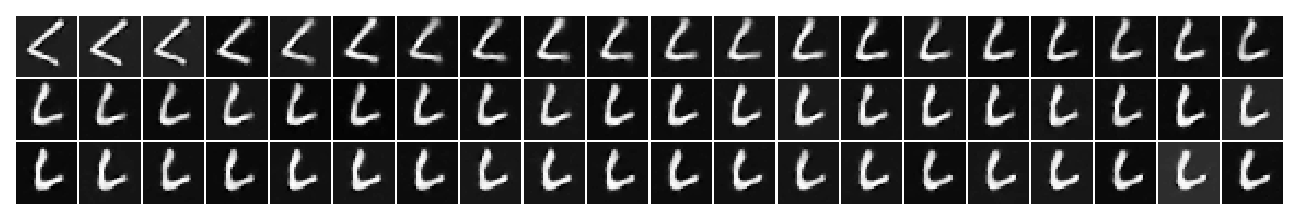

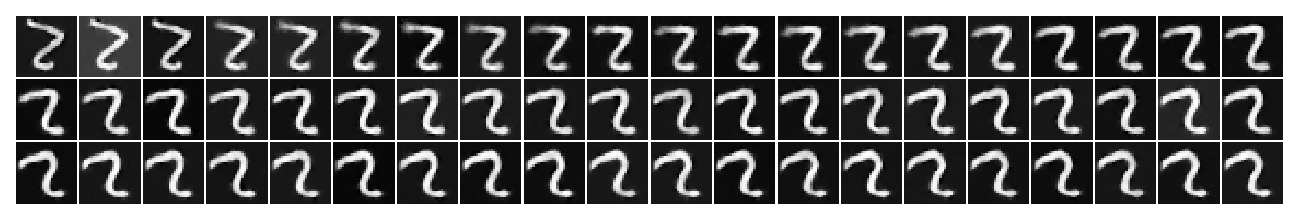

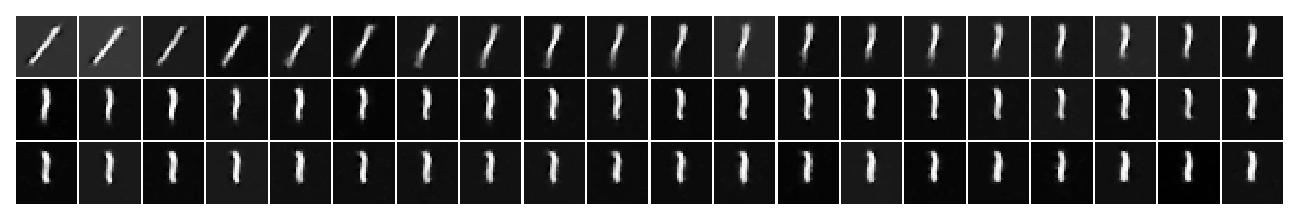

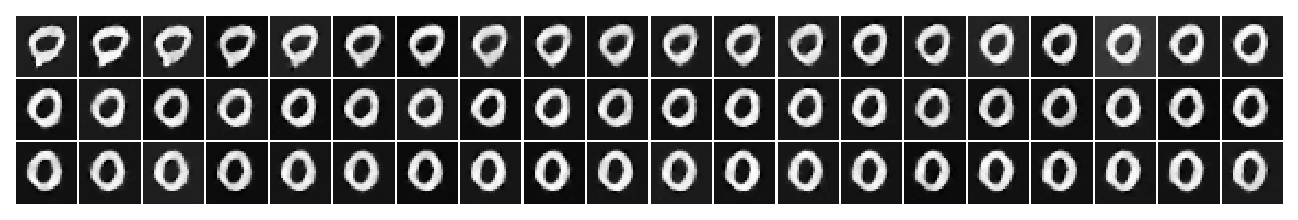

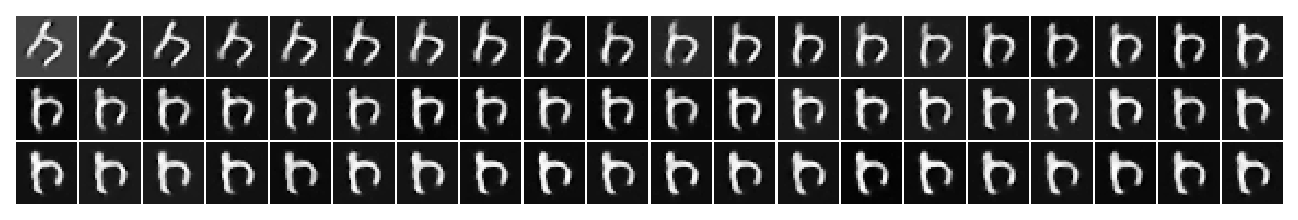

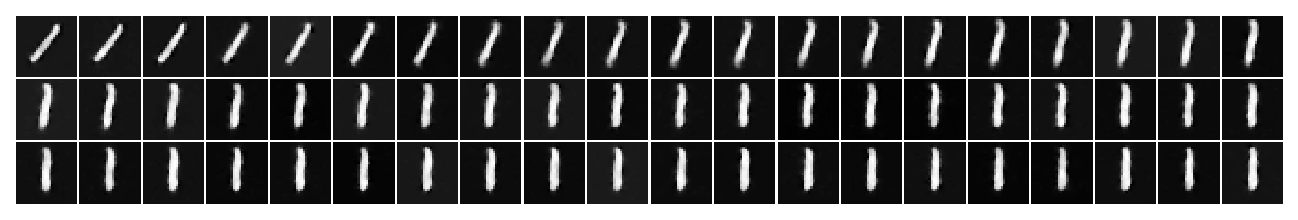

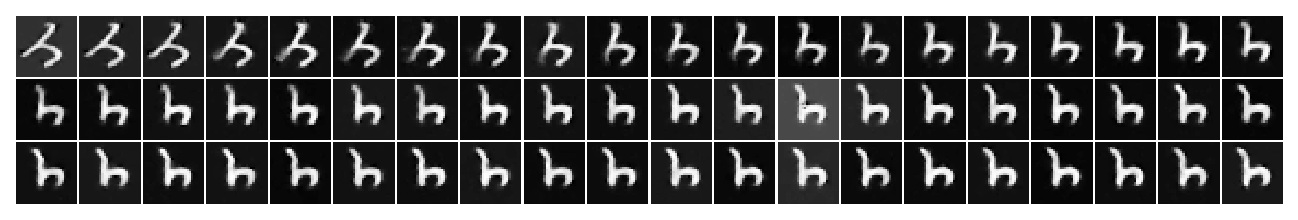

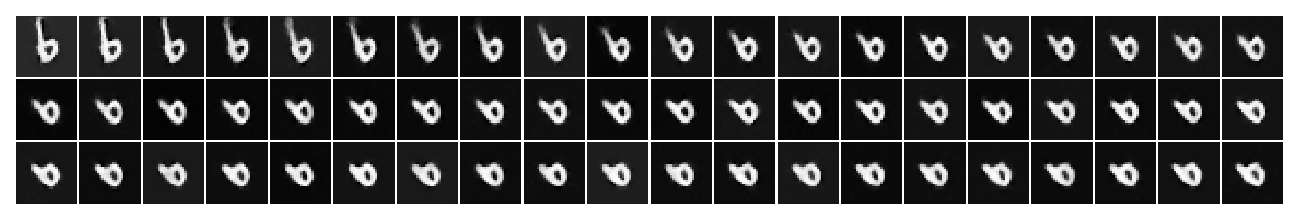

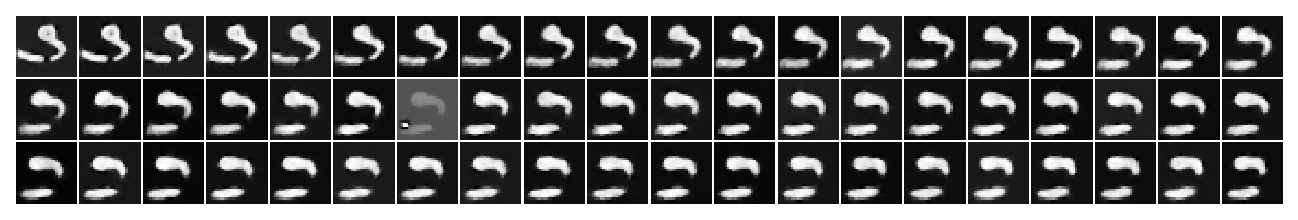

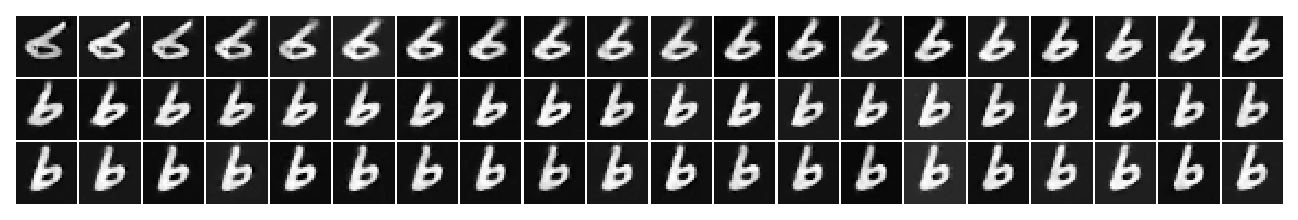

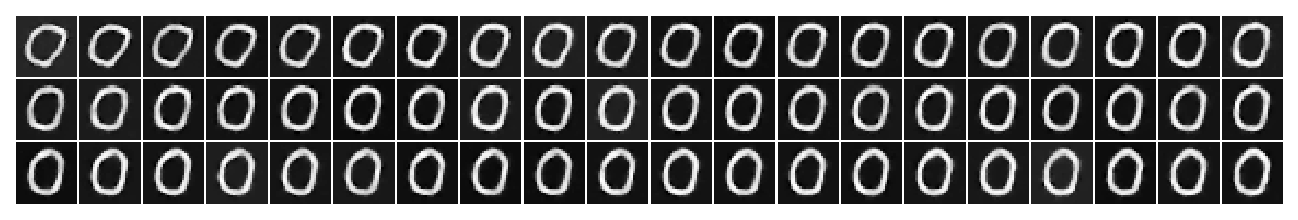

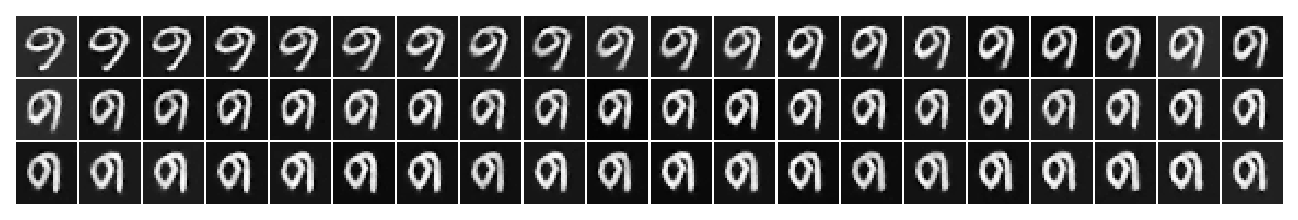

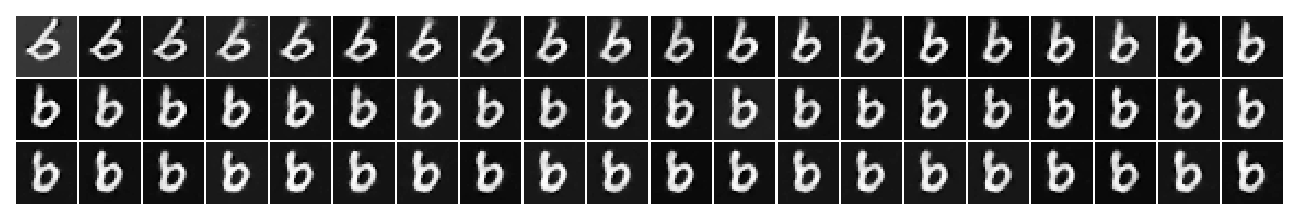

In [39]:
for i in range(len(samples_generated_x)):
    _ = plot_weights(samples_generated_x[i].squeeze(), nrows=3)